In [41]:
import pygimli as pg
import pygimli.meshtools as mt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import cartopy.crs as ccrs
from scipy.interpolate import griddata, RegularGridInterpolator
from scipy.spatial import KDTree
from pyproj import Proj
import pyproj
import pickle
import cartopy.feature as cfeature
import rasterio
from matplotlib.colors import Normalize, TwoSlopeNorm
import gepy
from matplotlib.patches import Rectangle
from scipy.ndimage import gaussian_filter
from matplotlib.colors import ListedColormap, Normalize


In [42]:
k0 = 2.7 # ((sediment))
k1 = 2.7 # crust
k2 = 3.0 # UM
k3 = 4.0 # LM #XX

RHP = 0.000000705

km = 1000 # multiplicative factor for m-km conversion

input_path = 'data_input.pickle'

area_coord_s = [-9.8e5,-9e5,-12.7e5, -13.5e5] # horizontal extent of the model
interface_resolutions = [100, 20, 10] # number of pixels in each interface


run_name = "LAB_MESH"
data_projection = ccrs.NorthPolarStereo()
plot_stuff = True

buffer_pixel = 1 # number of pixels of the roughest dataset as buffer
border_2 = 10

In [ ]:
# area_coord_s = [0, 3000000.0/2 , 0, 3000000.0/2 ]
# area_coord_s = [0, 3000000.0/2 , 3000000.0/2, 0 ] # XX huh?!

# data_projection = ccrs.SouthPolarStereo()
# input_path = "data_input_ANT.pickle"
# input_RHP_path = "RHP_data_input_ANT.pickle"

In [ ]:
with open(input_path, 'rb') as handle:
    data_calc,data_resolution = pickle.load(handle)
#data_calc = [[data_calc[0][0],data_calc[0][1],data_calc[0][2]],[data_calc[1][0],data_calc[1][1],np.ones(np.shape(data_calc[1][1])) * 1],[data_calc[2][0],data_calc[2][1],np.ones(np.shape(data_calc[2][2])) * 50000],[data_calc[3][0],data_calc[3][1],data_calc[3][2]]]
#data_calc = [[data_calc[0][0],data_calc[0][1],data_calc[0][2]],[data_calc[1][0],data_calc[1][1],np.ones(np.shape(data_calc[1][1])) * 1],[data_calc[2][0],data_calc[2][1],np.ones(np.shape(data_calc[2][2])) * 50000],[data_calc[3][0],data_calc[3][1],np.ones(np.shape(data_calc[3][2])) * 200000]]
#data_calc = [[data_calc[0][0],data_calc[0][1],np.ones(np.shape(data_calc[0][2])) * 100],[data_calc[1][0],data_calc[1][1],np.ones(np.shape(data_calc[1][2])) * 1],[data_calc[2][0],data_calc[2][1],data_calc[2][2]],[data_calc[3][0],data_calc[3][1],data_calc[3][2]]]

data_calc[2][2] = data_calc[2][2] *-1
data_calc[3][2] = data_calc[3][2] *-1

X, Y = data_calc[0][0],data_calc[0][1]
# Normalize X and Y to [0, 1]
# X_norm = (X - X.min()) / (X.max() - X.min())
# Y_norm = (Y - Y.min()) / (Y.max() - Y.min())
# bilinear_data = (1 - X_norm) * (1 - Y_norm)

#data_calc[3][2] = bilinear_data * 10000-200000



width = abs(area_coord_s[0]-area_coord_s[1])
height = abs(area_coord_s[2]-area_coord_s[3])
res_topo,res_moho,res_lab = (width/interface_resolutions[0],width/interface_resolutions[1],width/interface_resolutions[2])

resolutions = [width/i_r for i_r in interface_resolutions]

print(width,height)
print(resolutions)

buffer = max([resolutions]) *buffer_pixel


1500000.0 1500000.0
15000.0 75000.0 150000.0


In [65]:
def plot_data(x_plot,y_plot,c_plot,cmap="viridis",vmin=-1e9, vmax=1e9,cbar_label=""):
    if vmin==-1e9:
        vmin=np.nanmin(c_plot)
    if vmax==1e9:
        vmax=np.nanmax(c_plot)
    plt.figure()
    ax = plt.axes(projection=data_projection)
    sc = ax.pcolormesh(x_plot,y_plot,c_plot, cmap=cmap,vmin=vmin,vmax=vmax)
    ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, alpha=0.5, rotate_labels = False)
    ax.coastlines(resolution='50m',linewidth=0.5)
    plt.colorbar(sc,label=cbar_label)
    #plt.show()
    return ax

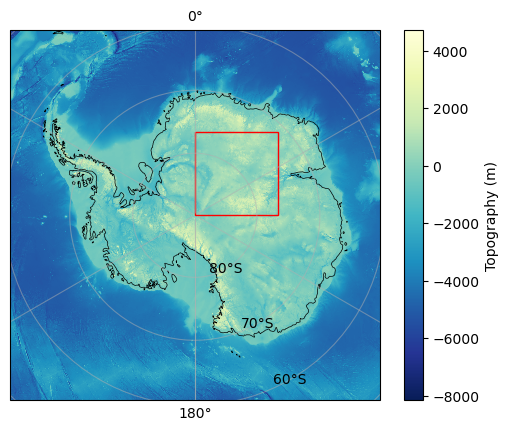

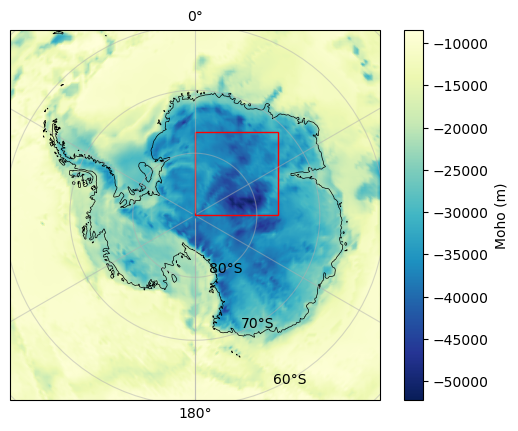

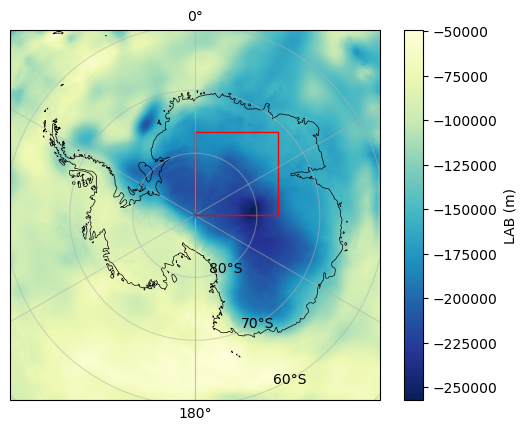

In [66]:

if plot_stuff:
    i=0 # topo
    ax = plot_data(data_calc[i][0],data_calc[i][1],data_calc[i][2],cmap='YlGnBu_r',cbar_label="Topography (m)")
    rect = patches.Rectangle((area_coord_s[0], area_coord_s[3]), area_coord_s[1]-area_coord_s[0], area_coord_s[2]-area_coord_s[3], linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    # i=1 # sed
    # ax = plot_data(data_calc[i][0],data_calc[i][1],data_calc[i][2],cmap='YlGnBu_r',cbar_label="Sediment (m)")
    # rect = patches.Rectangle((area_coord_s[0], area_coord_s[3]), area_coord_s[1]-area_coord_s[0], area_coord_s[2]-area_coord_s[3], linewidth=1, edgecolor='r', facecolor='none')
    # ax.add_patch(rect)
    i=2 # moho
    ax = plot_data(data_calc[i][0],data_calc[i][1],data_calc[i][2],cmap='YlGnBu_r',cbar_label="Moho (m)")
    rect = patches.Rectangle((area_coord_s[0], area_coord_s[3]), area_coord_s[1]-area_coord_s[0], area_coord_s[2]-area_coord_s[3], linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    i=3 # lab
    ax = plot_data(data_calc[i][0],data_calc[i][1],data_calc[i][2],cmap='YlGnBu_r',cbar_label="LAB (m)")
    rect = patches.Rectangle((area_coord_s[0], area_coord_s[3]), area_coord_s[1]-area_coord_s[0], area_coord_s[2]-area_coord_s[3], linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)



In [67]:
def in_area_s_ANT_realant(acs,x,y,g):
    '''
    Limit the size of the originial dataset to make interpolation easier

    Parameters
    ----------
    acs : research area coordinates
    x : xi of grid
    y : yi of grid
    g : data grid

    Returns
    -------
    x_s : smaller xi of grid
    y_s : smaller yi of grid
    grid_s : smaller data grid
    '''
    
    x = np.unique(x)
    y = np.unique(y)
    
    x_s = x[((acs[0])<=x) & (x<=(acs[1]))]
    y_s = y[((acs[2])<=y) & (y<=(acs[3]))]
    
    grid_s = g[np.ix_(((acs[2]<=y)) & (y<=(acs[3])),((acs[0])<=x) & (x<=(acs[1])))]
    grid_s = np.transpose(grid_s)
    
    print(len(x_s), len(y_s), np.shape(grid_s))
    return x_s,y_s,grid_s

In [68]:
def in_area_s_ANT(acs,x,y,g):
    '''
    Limit the size of the originial dataset to make interpolation easier

    Parameters
    ----------
    acs : research area coordinates
    x : xi of grid
    y : yi of grid
    g : data grid

    Returns
    -------
    x_s : smaller xi of grid
    y_s : smaller yi of grid
    grid_s : smaller data grid
    '''
    #buffer = 5000

    # Apply buffer to coordinates
    xmin, xmax, ymax,ymin  = acs

    xmin -= buffer
    xmax += buffer
    ymin -= buffer
    ymax += buffer

    #x = np.unique(x)
    #y = np.unique(y)
    x = x[0,:] # maybe differnt from unique??
    y = y[:,0]
    # Select indices within the buffered area
    x_mask = (x >= xmin) & (x <= xmax)
    y_mask = (y >= ymin) & (y <= ymax)
    
    x_s = x[x_mask]
    y_s = y[y_mask]
    
    # Apply masks to the data grid
    grid_s = g[np.ix_(y_mask, x_mask)]
    
    return x_s, y_s, grid_s

In [69]:
print(np.shape(data_calc[0][0]))

(5000, 5000)


In [70]:
#%% load data and cut it to size

xi_topo_s, yi_topo_s, grid_topo_s = in_area_s_ANT(area_coord_s,data_calc[0][0],data_calc[0][1],data_calc[0][2])
xi_sed_s, yi_sed_s, grid_sed_s    = in_area_s_ANT(area_coord_s,data_calc[1][0],data_calc[1][1],data_calc[1][2])
xi_moho_s, yi_moho_s, grid_moho_s = in_area_s_ANT(area_coord_s,data_calc[2][0],data_calc[2][1],data_calc[2][2])
xi_lab_s, yi_lab_s, grid_lab_s    = in_area_s_ANT(area_coord_s,data_calc[3][0],data_calc[3][1],data_calc[3][2])

#xi_topo_s, yi_topo_s, grid_topo_s = gepy.in_area_s(area_coord_s,data_calc[0][0],data_calc[0][1],data_calc[0][2])
#xi_sed_s, yi_sed_s, grid_sed_s    = gepy.in_area_s(area_coord_s,data_calc[1][0],data_calc[1][1],data_calc[1][2])
#xi_moho_s, yi_moho_s, grid_moho_s = gepy.in_area_s(area_coord_s,data_calc[2][0],data_calc[2][1],data_calc[2][2])
#xi_lab_s, yi_lab_s, grid_lab_s    = gepy.in_area_s(area_coord_s,data_calc[3][0],data_calc[3][1],data_calc[3][2])

#grid_topo_s= np.flipud(np.rot90(grid_topo_s)) # XX doof

# why is the result asymmetrical with a defined square area? are we hitting just before another data column/row?


xii_topo_s,yii_topo_s = np.meshgrid(xi_topo_s,yi_topo_s)
xii_sed_s,yii_sed_s   = np.meshgrid(xi_sed_s,yi_sed_s)
xii_moho_s,yii_moho_s = np.meshgrid(xi_moho_s,yi_moho_s)
xii_lab_s,yii_lab_s   = np.meshgrid(xi_lab_s,yi_lab_s)

x_int_t = np.linspace(area_coord_s[0],area_coord_s[1],int(abs((area_coord_s[0]-area_coord_s[1])/res_topo)))
y_int_t = np.linspace(area_coord_s[3],area_coord_s[2],int(abs((area_coord_s[3]-area_coord_s[2])/res_topo)))

x_int_m = np.linspace(area_coord_s[0],area_coord_s[1],int(abs((area_coord_s[0]-area_coord_s[1])/res_moho)))
y_int_m = np.linspace(area_coord_s[3],area_coord_s[2],int(abs((area_coord_s[3]-area_coord_s[2])/res_moho)))

x_int_l = np.linspace(area_coord_s[0],area_coord_s[1],int(abs((area_coord_s[0]-area_coord_s[1])/res_lab)))
y_int_l = np.linspace(area_coord_s[3],area_coord_s[2],int(abs((area_coord_s[3]-area_coord_s[2])/res_lab)))

xi_int_t,yi_int_t = np.meshgrid(x_int_t,y_int_t)
xi_int_m,yi_int_m = np.meshgrid(x_int_m,y_int_m)
xi_int_l,yi_int_l = np.meshgrid(x_int_l,y_int_l)

In [71]:
#np.shape(np.unique(xii_topo_s[0,:]))
#np.shape(np.unique(yii_topo_s[:,0]))
#np.shape(np.unique(xii_topo_s))

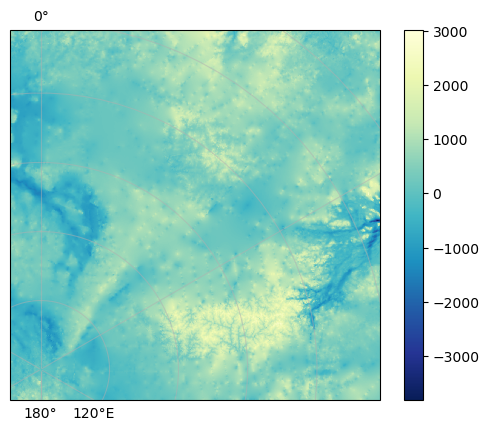

In [72]:
def plot_interface_s(i=0): # for now just topo
    vmin = np.nanmin(grid_topo_s)
    vmax = np.nanmax(grid_topo_s)
    ax = plt.axes(projection=data_projection)
    sc = ax.pcolormesh(xi_topo_s, yi_topo_s, grid_topo_s,cmap='YlGnBu_r',vmin=vmin,vmax=vmax)
    ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, alpha=0.5, rotate_labels = False)
    ax.coastlines(resolution='50m',linewidth=0.5)
    plt.colorbar(sc)
    plt.show()

if plot_stuff:
    plot_interface_s(0) # topo


In [73]:
# HOTFIX FOR THE EXTENT PROBLEM
#------------------------------

# #Clipping function to ensure values are within bounds
# def clip_values(values, min_val, max_val):
#     return np.clip(values, min_val, max_val)

# # Clipping xi_int_t and yi_int_t before interpolation
# xi_int_t = clip_values(xi_int_t, np.min(xi_topo_s), np.max(xi_topo_s))
# yi_int_t = clip_values(yi_int_t, np.min(yi_topo_s), np.max(yi_topo_s))

# # Clipping xi_int_m and yi_int_m before interpolation
# xi_int_m = clip_values(xi_int_m, np.min(xi_moho_s), np.max(xi_moho_s))
# yi_int_m = clip_values(yi_int_m, np.min(yi_moho_s), np.max(yi_moho_s))

# # Clipping xi_int_l and yi_int_l before interpolation
# xi_int_l = clip_values(xi_int_l, np.min(xi_lab_s), np.max(xi_lab_s))
# yi_int_l = clip_values(yi_int_l, np.min(yi_lab_s), np.max(yi_lab_s))


In [74]:
print("Shape of grid_moho_s:", grid_moho_s.shape)
print("Shape of xi_moho_s:", len(np.unique(xi_moho_s)))
print("Shape of yi_moho_s:", len(np.unique(yi_moho_s)))


Shape of grid_moho_s: (1349, 1349)
Shape of xi_moho_s: 1349
Shape of yi_moho_s: 1349


In [75]:
import numpy as np

# Print ranges before interpolation
print("Range of xi_topo_s before interpolation:", np.min(xi_topo_s), "to", np.max(xi_topo_s))
print("Range of yi_topo_s before interpolation:", np.min(yi_topo_s), "to", np.max(yi_topo_s))


print("Range of xi_int_t before interpolation:", np.min(xi_int_t), "to", np.max(xi_int_t))
print("Range of yi_int_t before interpolation:", np.min(yi_int_t), "to", np.max(yi_int_t))

Range of xi_topo_s before interpolation: -148681.53630726133 to 1648831.566313263
Range of yi_topo_s before interpolation: -148681.53630726133 to 1648831.5663132628
Range of xi_int_t before interpolation: 0.0 to 1500000.0
Range of yi_int_t before interpolation: 0.0 to 1500000.0


In [76]:

# Define the boundaries based on xi_int_t
xmin_int, xmax_int = np.min(xi_int_t), np.max(xi_int_t)

# Mask to find elements outside the range
xi_outside_mask = (xi_topo_s < xmin_int) | (xi_topo_s > xmax_int)

# Count the number of elements outside the interpolation area
num_xi_outside = np.sum(xi_outside_mask)

print(f"Number of xi_topo_s values outside xi_int_t: {num_xi_outside}")


Number of xi_topo_s values outside xi_int_t: 224


In [77]:
interp_topo = RegularGridInterpolator((np.unique(xi_topo_s),np.unique(yi_topo_s)),grid_topo_s.T)
grid_topo = interp_topo((xi_int_t,yi_int_t))
grid_topo[np.isnan(grid_topo)] = np.nanmean(grid_topo) # fill in nans just to be sure

interp_moho = RegularGridInterpolator((np.unique(xi_moho_s),np.unique(yi_moho_s)),grid_moho_s.T)
grid_moho = interp_moho((xi_int_m,yi_int_m))
grid_moho_for_topo = interp_moho((xi_int_t,yi_int_t))

interp_lab = RegularGridInterpolator((np.unique(xi_lab_s),np.unique(yi_lab_s)),grid_lab_s.T)
grid_lab = interp_lab((xi_int_l,yi_int_l))
grid_lab_for_topo = interp_lab((xi_int_t,yi_int_t))


# ACHTUNG: HIER WERDEN ALLE TRANSPONIERT!

interp_sed = RegularGridInterpolator((np.unique(xi_sed_s),np.unique(yi_sed_s)),grid_sed_s.T)
grid_sed = interp_sed((xi_int_t,yi_int_t),method='linear')

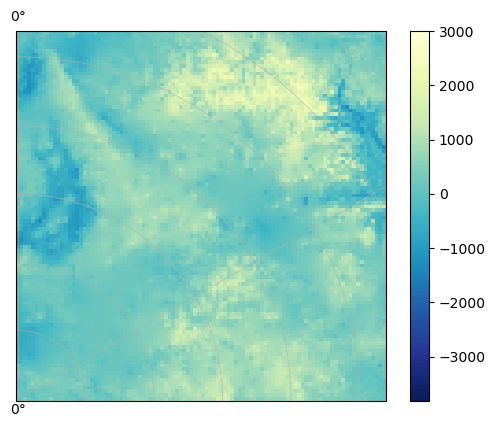

In [78]:


def plot_interface_interpol(i=0): # for now just topo
    vmin = np.nanmin(grid_topo_s)
    vmax = np.nanmax(grid_topo_s)
    ax = plt.axes(projection=data_projection)
    sc = ax.pcolormesh(xi_int_t,yi_int_t, grid_topo,cmap='YlGnBu_r',vmin=vmin,vmax=vmax)
    ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, alpha=0.5, rotate_labels = False)
    ax.coastlines(resolution='50m',linewidth=0.5)
    plt.colorbar(sc)
    plt.show()

if plot_stuff:
    plot_interface_interpol(0) # topo

In [79]:
#%% build the world

# create 3d mesh from the input data

# the +/- 10 are to create a slight buffer around the input data and world edge, there are issues
# in the mesh creation when edges of boundaries touch other boundaries
border = 10
border = buffer # ca 16000m - eine LAB pixelgröße

border = border_2

worldceiling = 10 # in km
worldfloor = -300 # hardcoded for now
start = [(area_coord_s[0]-border)/km,(area_coord_s[2]+border)/km,worldceiling]
end = [(area_coord_s[1]+border)/km,(area_coord_s[3]-border)/km,worldfloor] #https://www.pygimli.org/pygimliapi/_generated/pygimli.meshtools.html#pygimli.meshtools.createWorld
#end = [(area_coord_s[1]+border)/km,(area_coord_s[3]-border)/km,(-np.nanmax(grid_lab)-10)] #https://www.pygimli.org/pygimliapi/_generated/pygimli.meshtools.html#pygimli.meshtools.createWorld

world = mt.createWorld(start=start,end=end, worldMarker=False)


# create layer polygons and shift them to the correct height
mesh_moho = mt.createMesh2D(x_int_m/km,y_int_m/km)
mesh_lab  = mt.createMesh2D(x_int_l/km,y_int_l/km)

surface_moho = mt.createSurface(mesh_moho)
surface_lab  = mt.createSurface(mesh_lab)


surface_moho = gepy.fix_surface_height(surface_moho, x_int_m/km, y_int_m/km, grid_moho/km) # from here on out - we deal in km
surface_lab  = gepy.fix_surface_height(surface_lab, x_int_l/km, y_int_l/km, grid_lab/km)

for boundary in surface_moho.boundaries():
    boundary.setMarker(6)
for boundary in surface_lab.boundaries():
    boundary.setMarker(7)

In [80]:
#surface_topo,surface_sed = gepy.create_sed_interface(x_int_t, y_int_t, grid_topo, grid_sed) # die km werden in gepy noch berücksichtigt
# ^^ triangles dont seem to work at this resolution... :(
# vv we'll have to work with squares then
mesh_topo = mt.createMesh2D(x_int_t/km,y_int_t/km)
surface_topo  = mt.createSurface(mesh_topo)
surface_topo = gepy.fix_surface_height(surface_topo, x_int_t/km, y_int_t/km, grid_topo/km)

for boundary in surface_topo.boundaries():
    boundary.setMarker(4)



In [81]:
geometry = world + surface_topo + surface_moho + surface_lab

In [82]:
#geometry = world
#geometry.add(surface_topo) # or merge??

In [83]:
#geometry += surface_topo

In [84]:
#geometry += surface_moho

In [85]:
#geometry  += surface_lab # + surface_sed

In [86]:
mesh = mt.createMesh(geometry,quality=34)#34,area=2.5)

In [87]:
if plot_stuff and False:
    pg.show(mesh, label='Mesh', markers=True,  alpha=1)
    pg.show(surface_topo, label='Topo', markers=True,  alpha=1)
    pg.show(surface_moho, label='Moho', markers=True,  alpha=1)
    pg.show(surface_lab, label='LAB', markers=True,  alpha=1)
    #pg.show(surface_topo, showMesh=True, alpha=1, data=grid_topo.flatten())
    plt.legend()
    plt.show()


    grid_topo_flat = grid_topo.flatten()
    grid_moho_flat = grid_moho.flatten()
    grid_lab_flat = grid_lab.flatten()

    combined_data = np.concatenate([[np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],grid_topo_flat, grid_moho_flat, grid_lab_flat])
    pg.show(geometry, showMesh=True, alpha=0.7, data=combined_data)

    print(mesh)
    pg.show(mesh,showMesh=True,alpha=0.7)

    print(geometry)
    pg.show(geometry,showMesh=True,alpha=0.7)


In [88]:
'''
Radiogenic Heat Production:
'''

with open(input_RHP_path, 'rb') as handle:
    [xi_A,yi_A,grid_A] = pickle.load(handle)
#    grid_A = np.ones(np.shape(grid_A))*3.1863201703538226e-07 *km*km*km
    #grid_A = np.ones(np.shape(grid_A))*3.315482211738545e-07 *km*km*km #  in area

#A = np.ones(np.shape(data_calc[0][2]))*RHP
#xi_topo,yi_topo = data_calc[0][0], data_calc[0][1] # maybe still needed for debugging
#xi_smos,yi_smos = data_calc[0][0], data_calc[0][1]


#A = np.ones(np.shape(A))*RHP



A = grid_A /km /km /km
#xi_smos,yi_smos = xi_A,yi_A


dx = np.abs(xi_A[0,1] - xi_A[0,0])  # x spacing (horizontal)
dy = np.abs(yi_A[1,0] - yi_A[0,0])  # y spacing (vertical)

# Expand bounds by one pixel in each direction
expanded_coords = [
    area_coord_s[0] - 5*dx,  # xmin - 1 pixel
    area_coord_s[1] + 5*dx,  # xmax + 1 pixel
    area_coord_s[2] - 5*dy,  # ymin - 1 pixel
    area_coord_s[3] + 5*dy   # ymax + 1 pixel
]

#xi_smos_s, yi_smos_s, A_s = gepy.in_area_s(area_coord_s,xi_A,yi_A,A)
xi_smos_s, yi_smos_s, A_s = in_area_s_ANT(expanded_coords,xi_A,yi_A,A)
xii_smos_s,yii_smos_s   = np.meshgrid(xi_smos_s,yi_smos_s)
    
res_HP = width/8
    
x_int_HP,y_int_HP = np.arange(area_coord_s[0],area_coord_s[1]+res_HP,res_HP),  np.arange(area_coord_s[3],area_coord_s[2]+res_HP,res_HP)
xi_int_HP,yi_int_HP = np.meshgrid(x_int_HP,y_int_HP)

grid_A  = griddata((xii_smos_s.flatten(), yii_smos_s.flatten()), np.transpose(A_s).flatten(), (xi_int_HP,yi_int_HP),fill_value=np.nan)

#grid_A = np.ones(np.shape(grid_A))*np.nanmean(grid_A) /km /km /km #!!



# Flatten original grid and values
x_coords = xii_smos_s.flatten()
y_coords = yii_smos_s.flatten()
values = A_s.flatten()
#values = (np.ones(np.shape(A_s))*np.nanmean(A_s) /km /km /km).flatten() #!!


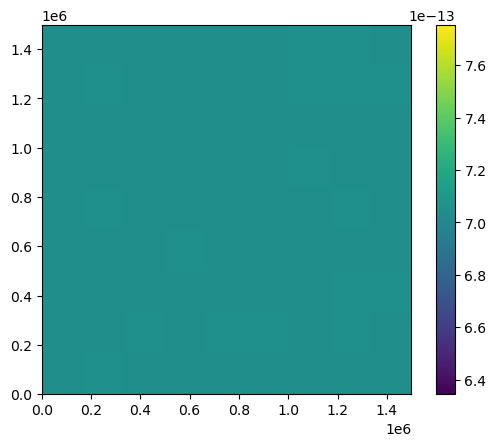

In [89]:
plt.imshow(grid_A, extent=[np.min(xi_int_t), np.max(xi_int_t), np.min(yi_int_t), np.max(yi_int_t)], cmap="viridis")#, norm=divnorm)
plt.colorbar()

In [90]:
# import numpy as np
# from scipy import ndimage

# # grid_A is your 2D array with NaNs around the border
# nan_mask = np.isnan(grid_A)

# # Get indices of nearest non-NaN cells for each NaN
# # 1. Create mask of valid entries
# valid_mask = ~nan_mask

# # 2. Get nearest-neighbor indices for each element
# # This returns arrays of indices pointing to the nearest valid entry
# idx = ndimage.distance_transform_edt(nan_mask,
#                                      return_distances=False,
#                                      return_indices=True)

# # 3. Use those indices to fill the NaNs from the nearest non-NaN values
# grid_filled = grid_A.copy()
# grid_filled[nan_mask] = grid_A[tuple(idx[:, nan_mask])]


# plt.imshow(grid_filled,
#            extent=[np.min(xi_int_t), np.max(xi_int_t),
#                    np.min(yi_int_t), np.max(yi_int_t)],
#            cmap="viridis")


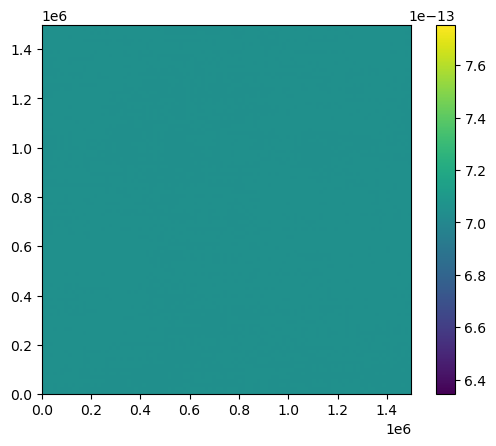

In [91]:


# Define new grid
#xi_int_t, yi_int_t = np.meshgrid(x_int_t, y_int_t)

# Perform cubic interpolation
z_interp = griddata((x_coords, y_coords), values, (xi_int_t, yi_int_t), method='linear')

# Fill NaN values with nearest neighbor interpolation
z_interp_nearest = griddata((x_coords, y_coords), values, (xi_int_t, yi_int_t), method='nearest')

# Replace NaNs in cubic with nearest values
z_interp[np.isnan(z_interp)] = z_interp_nearest[np.isnan(z_interp)]

#grid_A = z_interp
# Apply Gaussian smoothing to blend edges
z_interp_smooth = gaussian_filter(z_interp, sigma=5) 
grid_A = np.fliplr(np.flipud(z_interp_smooth))

grid_A_for_topo = grid_A

plt.imshow(grid_A_for_topo, extent=[np.min(xi_int_t), np.max(xi_int_t), np.min(yi_int_t), np.max(yi_int_t)], cmap="viridis")#, norm=divnorm)
plt.colorbar()

In [92]:
#%% apply correct markers to cells and nodes, and create temp and force vectors

grid_xy_ts = np.array(list(zip(xi_int_t.flatten()/km,yi_int_t.flatten()/km)))
tree_ts = KDTree(grid_xy_ts)
grid_xy_m = np.array(list(zip(xi_int_m.flatten()/km,yi_int_m.flatten()/km)))
tree_m = KDTree(grid_xy_m)
grid_xy_l = np.array(list(zip(xi_int_l.flatten()/km,yi_int_l.flatten()/km)))
tree_l = KDTree(grid_xy_l)

# create lists for temperature and heat production that are to be applied to the nodes

force = np.zeros(mesh.nodeCount())
# Tnode = []
#print(len(mesh.nodes()))

In [93]:

for i, node in enumerate(mesh.nodes()):
    #print(i)
    x,y,z = node.pos()
    z_topo = gepy.compare_to_plane(x,y,grid_topo,grid_xy_ts,tree_ts)
    #z_sed = gepy.compare_to_plane(x,y,(grid_topo-grid_sed),grid_xy_ts,tree_ts)
    z_moho = gepy.compare_to_plane(x,y,grid_moho,grid_xy_m,tree_m)
    #z_lab = gepy.compare_to_plane(x,y,-grid_lab,grid_xy_l,tree_l)
    
    idx_A,idy_A = np.argmin(np.abs(x_int_t/km-x)),np.argmin(np.abs(y_int_t/km-y))
    
    #if z >= z_moho and z <= z_sed:
    if z >= z_moho and z <= z_topo:
        force[i] = grid_A_for_topo[idy_A,idx_A]
        #force[i] = RHP
        #force[i] = np.nanmean(grid_A_for_topo)
    else:
        force[i] = 0

c:\Users\User\Documents\HIWI\GHF_forward_modelling_FRANKENSTEIN\gepy.py:215: RuntimeWarning: invalid value encountered in scalar divide
  F = (-x*norm[0] - y*norm[1] - D)/norm[2]
c:\Users\User\Documents\HIWI\GHF_forward_modelling_FRANKENSTEIN\gepy.py:215: RuntimeWarning: divide by zero encountered in scalar divide
  F = (-x*norm[0] - y*norm[1] - D)/norm[2]


In [94]:

    
# apply correct marker to the cells
for i,cell in enumerate(mesh.cells()):
    center = cell.center()
    x, y, z = center.x(), center.y(), center.z()
    
    # z_topo = gepy.compare_to_plane(x,y,grid_topo,grid_xy_ts,tree_ts)
    # z_sed = gepy.compare_to_plane(x,y,(grid_topo-grid_sed),grid_xy_ts,tree_ts)
    # z_moho = gepy.compare_to_plane(x,y,-grid_moho,grid_xy_m,tree_m)
    # z_lab = gepy.compare_to_plane(x,y,-grid_lab,grid_xy_l,tree_l)

    z_topo = gepy.compare_to_plane(x,y,grid_topo,grid_xy_ts,tree_ts)
    #z_sed = gepy.compare_to_plane(x,y,(grid_topo-grid_sed),grid_xy_ts,tree_ts)
    z_moho = gepy.compare_to_plane(x,y,grid_moho,grid_xy_m,tree_m)
    z_lab = gepy.compare_to_plane(x,y,grid_lab,grid_xy_l,tree_l)
    
    # if z < z_topo:
    #     cell.setMarker(4)
    # if z < z_sed:
    #     cell.setMarker(5)
    # if z < z_moho:
    #     cell.setMarker(6)
    # if z < z_lab:
    #     cell.setMarker(7)


    if z < z_topo and z >= z_moho:
        cell.setMarker(5)
    #if z < z_sed:
    #    cell.setMarker(5)
    elif z < z_moho and z >= z_lab:
        cell.setMarker(6)
    elif z < z_lab:
        cell.setMarker(7)

pg.show(mesh,showMesh=True,alpha=0.7)

Widget(value='<iframe src="http://localhost:63026/index.html?ui=P_0x1b800ee6550_2&reconnect=auto" class="pyvis…

(<pyvista.plotting.plotter.Plotter at 0x1b800ee6550>, None)

In [95]:
#%% run calc and get shf



#a_test = {1: 1.0*km, 4: k0*km, 5: k1*km, 6: k2*km, 7: k3*km,        0: 1.0*km, 8: 1.0*km, 9: 1.0*km, 10: 1.0*km}

k_insulate = 0.1 # insulate the top of the model, so that the heat does not escape
a_test = {1: 1.0*km, 4: k0*km, 5: k1*km, 6: k2*km, 7: k3*km,        0: k_insulate*km, 8: k_insulate*km, 9: k_insulate*km, 10: k_insulate*km}
bc_test = {'Dirichlet': {7: 1315, 4: 0}}

T = pg.solver.solveFiniteElements(mesh, a=a_test, f=force*km*km*km, bc=bc_test,verbose=True)#{'Node': Tnode}

T_list = [T[i] for i in range(len(T))]

topcoord = []
for i in range(len(x_int_t)):
    for j in range(len(y_int_t)):
        topcoord.append([x_int_t[i]/km,y_int_t[j]/km,(grid_topo[j,i]-5)/km]) # magic number 5 is to avoid problems with the top of the mesh

gradientTop = pg.solver.grad(mesh, T, topcoord)

geology_list = []

shf = np.zeros(len(gradientTop))
for i in range(len(gradientTop)):
    point = pg.RVector3(topcoord[i][0],topcoord[i][1],topcoord[i][2])
    cell = mesh.findCell(point)
    geology = cell.marker()
    geology_list.append(geology)
    if geology == 5:   
        #shf[i] = np.linalg.norm(gradientTop[i,:])*k1
        shf[i] = gradientTop[i,2]*k1*-1
    elif geology == 4:
        #shf[i] = np.linalg.norm(gradientTop[i,:])*k0
        shf[i] = gradientTop[i,2]*k0*-1

shf_3D = np.transpose(np.reshape(shf,(len(x_int_t),len(y_int_t))))
gradientTop_rs = np.reshape(gradientTop[:,2],(len(x_int_t),len(y_int_t)))


Mesh:  Mesh: Nodes: 916144 Cells: 3075476 Boundaries: 6841625
Assembling time:  1125.877753
Solving time:  12.1003382


In [96]:


mesh["T"] = T

gradient = pg.solver.grad(mesh, T)
#pg.show(mesh,data=gradient[:,2],filter={'clip':{'origin':(1050, 0, 0)},})
mesh["T_gradient"] = gradient

In [97]:
if plot_stuff:
    pg.show(mesh,data=T,showMesh=True, label='Temperature in C', cMap="inferno", alpha=0.7)


Widget(value='<iframe src="http://localhost:63026/index.html?ui=P_0x1b8c4924cd0_3&reconnect=auto" class="pyvis…

In [98]:
def calculate_surface_heat_flow_1D():
    """
    Calculates surface heat flow using fixed temperature boundary conditions.
    
    Parameters:
    grid_topo (numpy array): Topography heights (m)
    grid_lab_for_topo (numpy array): LAB depth (m)
    grid_moho_for_topo (numpy array): Moho depth (m)
    k1 (float): Thermal conductivity of the crust (W/mK)
    k2 (float): Thermal conductivity of the upper mantle (W/mK)
    k3 (float): Thermal conductivity of the lower mantle (W/mK) [not used explicitly if LAB is within UM]
    A_1D (float): Radiogenic heat production in the crust (W/m^3)
    
    Returns:
    numpy array: Surface heat flow values (W/m^2)
    """
    
    # Compute crust and mantle thicknesses
    crust_thickness = grid_moho_for_topo - grid_topo
    mantle_thickness = grid_lab_for_topo - grid_moho_for_topo
    
    # Fixed boundary conditions
    T_surface = 0.0  # °C
    T_LAB = 1315.0   # °C
    
    # Temperature gradient in the crust (including heat production term)
    q_moho = (A_1D * crust_thickness) + (k1 * (T_LAB - T_surface) / (crust_thickness + mantle_thickness))
    
    # Heat flow through the mantle (assuming conduction only)
    q_surface = q_moho + (A_1D * crust_thickness**2) / 2
    
    return q_surface

min 13.973892 max 25.775417 mean 19.615552


<GeoAxes: >

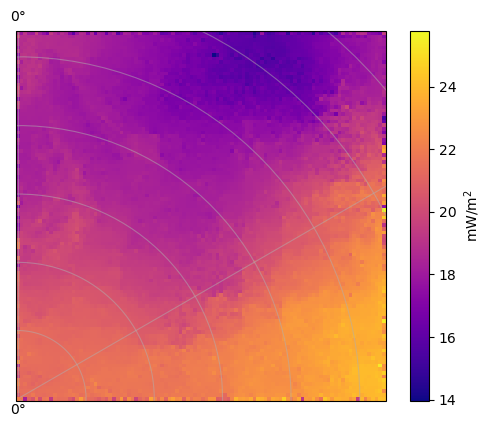

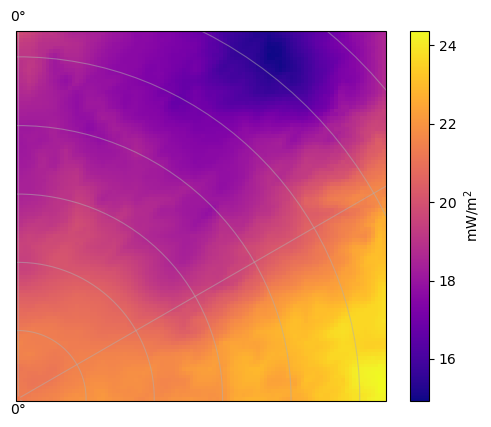

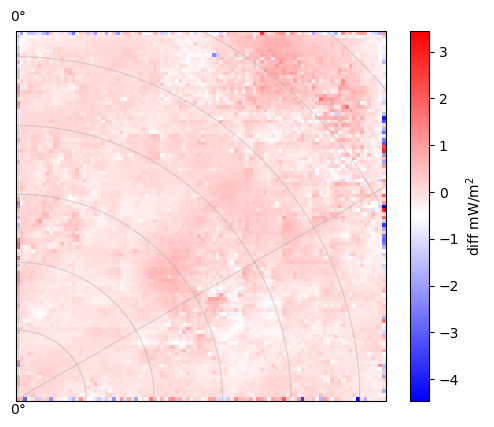

In [99]:
#%% Plot data and compare to 1D result

print("min %f max %f mean %f" %(np.min(shf_3D), np.max(shf_3D), np.mean(shf_3D)))


plot_data(x_int_t, y_int_t, shf_3D, cmap="plasma", cbar_label='mW/m$^2$')

A_1D = RHP
A_1D = grid_A_for_topo # 500x500, der rest is 30x40

grid_moho_t = grid_moho_for_topo - grid_topo
grid_lab_t = grid_lab_for_topo - grid_moho_for_topo
shf_1D = ((1315-0+(A_1D*grid_moho_t*grid_lab_t)/k2+(1/2*A_1D*grid_moho_t**2)/k1) / (grid_lab_t/k2 + grid_moho_t/k1) * km) *-1


#shf_1D = calculate_surface_heat_flow_1D() # doesnt work

plot_data(x_int_t, y_int_t, shf_1D, cmap="plasma", cbar_label='mW/m$^2$')

plot_data(x_int_t, y_int_t, shf_3D-shf_1D, cmap="bwr", cbar_label='diff mW/m$^2$')


In [100]:
# Windows:
import winsound
duration = 5000  # milliseconds
freq = 440  # Hz
winsound.Beep(freq, duration)

# unix
# import os
# duration = 1  # seconds
# freq = 440  # Hz
# os.system('play -nq -t alsa synth {} sine {}'.format(duration, freq))


with open('output/'+run_name+'_output.pickle', 'wb') as handle:
        pickle.dump([shf_3D,shf_1D], handle, protocol=pickle.HIGHEST_PROTOCOL)


mesh.exportVTK('output/'+run_name+"_mesh.vtk")
#with open('output/'+run_name+"mesh.vtk") as f:
#        print(f.read())